<div style="display: flex; align-items: center; justify-content: flex-start; text-align: left;">
    <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/6/68/Logo_universidad_icesi.svg/960px-Logo_universidad_icesi.svg.png" width="300" style="margin-right: 20px;">
    <div>
        <h3 style="margin: 0;">FACULTAD BARBERI DE INGENIERÍA, DISEÑO Y CIENCIAS APLICADAS</h3>
        <h3 style="margin: 0;">ALGORITMOS Y PROGRAMACIÓN III</h3>
    </div>
</div>

# Notebook 01 — Análisis Exploratorio de Datos (EDA)

Integrantes:
- ANGY MARIA HURTADO OSORIO A00401755
- HIDEKI TAMURA HERNANDEZ A00348618
- DAVID VERGARA LAVERDE A00402237


---

## Objetivo

Este notebook desarrolla la etapa de **Comprensión de los Datos** dentro de la metodología CRISP-DM aplicada al proyecto de clasificación de calidad de frutas. El análisis se estructura en torno a cuatro preguntas concretas:

1. ¿Cuántas imágenes hay por clase y existe desbalanceo que pueda sesgar el entrenamiento?
2. ¿Las imágenes presentan variabilidad suficiente de tamaño, color y apariencia para generalizar?
3. ¿Las diferencias visuales entre clases son detectables en el espacio de color, o el modelo necesitará aprender patrones más complejos?
4. ¿El pipeline de preprocesamiento definido en `preprocess.py` produce imágenes coherentes con lo que se le entregará al modelo?

Los resultados aquí obtenidos justifican las decisiones de preprocesamiento, balanceo y selección de modelos en las etapas posteriores del proyecto.

---

## Alcance dentro del proyecto

El dataset base proviene de [Fruit Quality Classification (Kaggle)](https://www.kaggle.com/datasets/ryandpark/fruit-quality-classification), que incluye las carpetas `Bad Quality_Fruits`, `Good Quality_Fruits` y `mix quality_fruits`. La clase **Regular** se construye a partir de dos fuentes: recortes anotados manualmente de las imágenes en `mix quality_fruits` y fotografías propias tomadas en plazas de mercado y supermercados, tal como lo establece el enunciado del proyecto (sección 2.2).

Este notebook trabaja sobre `data/raw/` antes de que corra `preprocess.py`. La sección 8 verifica el resultado del preprocesamiento sobre `data/processed/metadata.csv`.


## 0. Configuración e importaciones

Se definen las rutas del repositorio, la paleta de colores por clase y los parámetros globales de visualización. La variable `QUALITY_COLORS` asigna un color semántico a cada clase (rojo → Bad, verde → Good, naranja → Regular) para mantener coherencia visual en todas las figuras del notebook.


In [1]:
import os
import math
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import cv2
from PIL import Image
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')


plt.rcParams.update({
    'figure.dpi':      150,
    'axes.titlesize':  13,
    'axes.labelsize':  11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'font.family':     'DejaVu Sans',
})
sns.set_theme(style='whitegrid', palette='muted')

# ── Rutas
RAW_DIR       = Path('../data/raw')
PROCESSED_DIR = Path('../data/processed')
FIGURES_DIR   = Path('../docs/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ── Clases oficiales del problema.
CLASS_ORDER = ['Bad', 'Good', 'Regular']

# ── Paleta de colores por clase
QUALITY_COLORS = {
    'Bad':     '#e74c3c',   # rojo
    'Good':    '#2ecc71',   # verde
    'Regular': '#f39c12',   # naranja
}

QUALITY_MAP = {
    'bad':     'Bad',
    'good':    'Good',
    'regular': 'Regular',
}

SUPPORTED_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

print(' Configuración lista')

 Configuración lista


---
## 1. Inventario del dataset

Se recorre `data/raw/` y se construye un DataFrame con una fila por imagen. Las carpetas cuyo nombre no contiene ninguna de las tres palabras clave (`bad`, `good`, `regular`) se registran como ignoradas — en particular `mix quality_fruits`, cuyas imágenes se incorporan al dataset después de anotación manual.


In [2]:
records = []
ignored_root_folders = []

if not RAW_DIR.exists():
    raise FileNotFoundError(
        f'No se encontró RAW_DIR={RAW_DIR}. '
        'Verifica que el notebook se ejecute desde la carpeta notebooks/ '
        'o ajusta la ruta en la celda de configuración.'
    )

for quality_folder in sorted(RAW_DIR.iterdir()):
    if not quality_folder.is_dir():
        continue

    quality_name = None
    for key, val in QUALITY_MAP.items():
        if key in quality_folder.name.lower():
            quality_name = val
            break

    if quality_name is None:
        ignored_root_folders.append(quality_folder.name)
        continue

    for fruit_folder in sorted(quality_folder.iterdir()):
        if not fruit_folder.is_dir():
            continue

        # Ejemplo: Apple_Bad -> Apple
        fruit_type = fruit_folder.name.split('_')[0]

        for img_path in sorted(fruit_folder.iterdir()):
            if img_path.suffix.lower() in SUPPORTED_EXTS:
                stat = img_path.stat()
                records.append({
                    'path':         str(img_path),
                    'quality':      quality_name,
                    'fruit':        fruit_type,
                    'filename':     img_path.name,
                    'ext':          img_path.suffix.lower(),
                    'size_bytes':   stat.st_size,
                })

df = pd.DataFrame(records, columns=['path', 'quality', 'fruit', 'filename', 'ext', 'size_bytes'])

if df.empty:
    raise ValueError(
        'No se encontraron imágenes válidas. Revisa la estructura de data/raw/ '
        'y las extensiones permitidas en SUPPORTED_EXTS.'
    )

quality_counts_raw = df['quality'].value_counts().reindex(CLASS_ORDER, fill_value=0)
missing_classes = quality_counts_raw[quality_counts_raw == 0].index.tolist()

print(f'Total de imágenes encontradas: {len(df)}')
print(f'Clases de calidad detectadas: {df["quality"].unique().tolist()}')
print(f'Tipos de fruta detectados  : {df["fruit"].unique().tolist()}')
print('\nDistribución por calidad:')
display(quality_counts_raw.to_frame('n_imagenes'))

if ignored_root_folders:
    print('\nCarpetas raíz ignoradas porque no pertenecen a las 3 clases oficiales:')
    for folder in ignored_root_folders:
        print(f'  - {folder}')

if missing_classes:
    print('\nALERTA: faltan imágenes para estas clases oficiales:', missing_classes)
    print('Antes de entrenar, corrige la estructura o ubicación de esas carpetas.')
else:
    print('\nValidación OK: las tres clases oficiales tienen imágenes.')

display(df.head(10))


Total de imágenes encontradas: 28395
Clases de calidad detectadas: ['Bad', 'Good', 'Regular']
Tipos de fruta detectados  : ['Apple', 'Banana', 'Guava', 'Lime', 'Orange', 'Pomegranate']

Distribución por calidad:


,n_imagenes
quality,
Bad,9142
Good,14599
Regular,4654



Validación OK: las tres clases oficiales tienen imágenes.


,path,quality,fruit,filename,ext,size_bytes
0,../data/raw/Bad Quality_Fruits/Apple_Bad/IMG-2...,Bad,Apple,IMG-20260603-WA0146.jpg,.jpg,713242
1,../data/raw/Bad Quality_Fruits/Apple_Bad/IMG-2...,Bad,Apple,IMG-20260603-WA0148.jpg,.jpg,926333
2,../data/raw/Bad Quality_Fruits/Apple_Bad/IMG-2...,Bad,Apple,IMG-20260603-WA0150.jpg,.jpg,865645
3,../data/raw/Bad Quality_Fruits/Apple_Bad/IMG-2...,Bad,Apple,IMG-20260603-WA0152.jpg,.jpg,855014
4,../data/raw/Bad Quality_Fruits/Apple_Bad/IMG-2...,Bad,Apple,IMG-20260603-WA0154.jpg,.jpg,820592
5,../data/raw/Bad Quality_Fruits/Apple_Bad/IMG-2...,Bad,Apple,IMG-20260603-WA0156.jpg,.jpg,676815
6,../data/raw/Bad Quality_Fruits/Apple_Bad/IMG-2...,Bad,Apple,IMG-20260603-WA0158.jpg,.jpg,1261626
7,../data/raw/Bad Quality_Fruits/Apple_Bad/IMG-2...,Bad,Apple,IMG-20260603-WA0160.jpg,.jpg,1188719
8,../data/raw/Bad Quality_Fruits/Apple_Bad/IMG-2...,Bad,Apple,IMG-20260603-WA0162.jpg,.jpg,1280057
9,../data/raw/Bad Quality_Fruits/Apple_Bad/IMG-2...,Bad,Apple,IMG-20260603-WA0164.jpg,.jpg,1052832


**Qué observar.** La tabla y los conteos muestran si las tres clases están presentes y con cuántas imágenes cuenta cada una antes de la anotación manual de `mix`. Si el conteo de Regular es notablemente menor al de Bad o Good, eso justifica aumentar la recolección propia o extraer más recortes de `mix`. Si aparece alguna clase con cero imágenes, el flujo posterior fallará y hay que corregir la estructura de `data/raw/` antes de continuar.


---
## 2. Distribución de clases y desbalanceo

El desbalanceo de clases es uno de los problemas más frecuentes en datasets de visión por computadora construidos con fuentes heterogéneas. Un modelo entrenado con clases desbalanceadas tiende a predecir siempre la clase mayoritaria, obteniendo una accuracy alta pero una utilidad real baja. Para cuantificar el desbalanceo se usa el **Imbalance Ratio** (IR), definido como:

$$IR = \frac{N_{\max}}{N_{\min}}$$

donde $N_{\max}$ y $N_{\min}$ son los tamaños de la clase con más y menos imágenes, respectivamente. Un IR ≤ 1.5 se considera balanceado; entre 1.5 y 3.0 requiere `class_weight='balanced'`; por encima de 3.0 se recomienda oversampling o aumento de datos focalizado en la clase minoritaria.


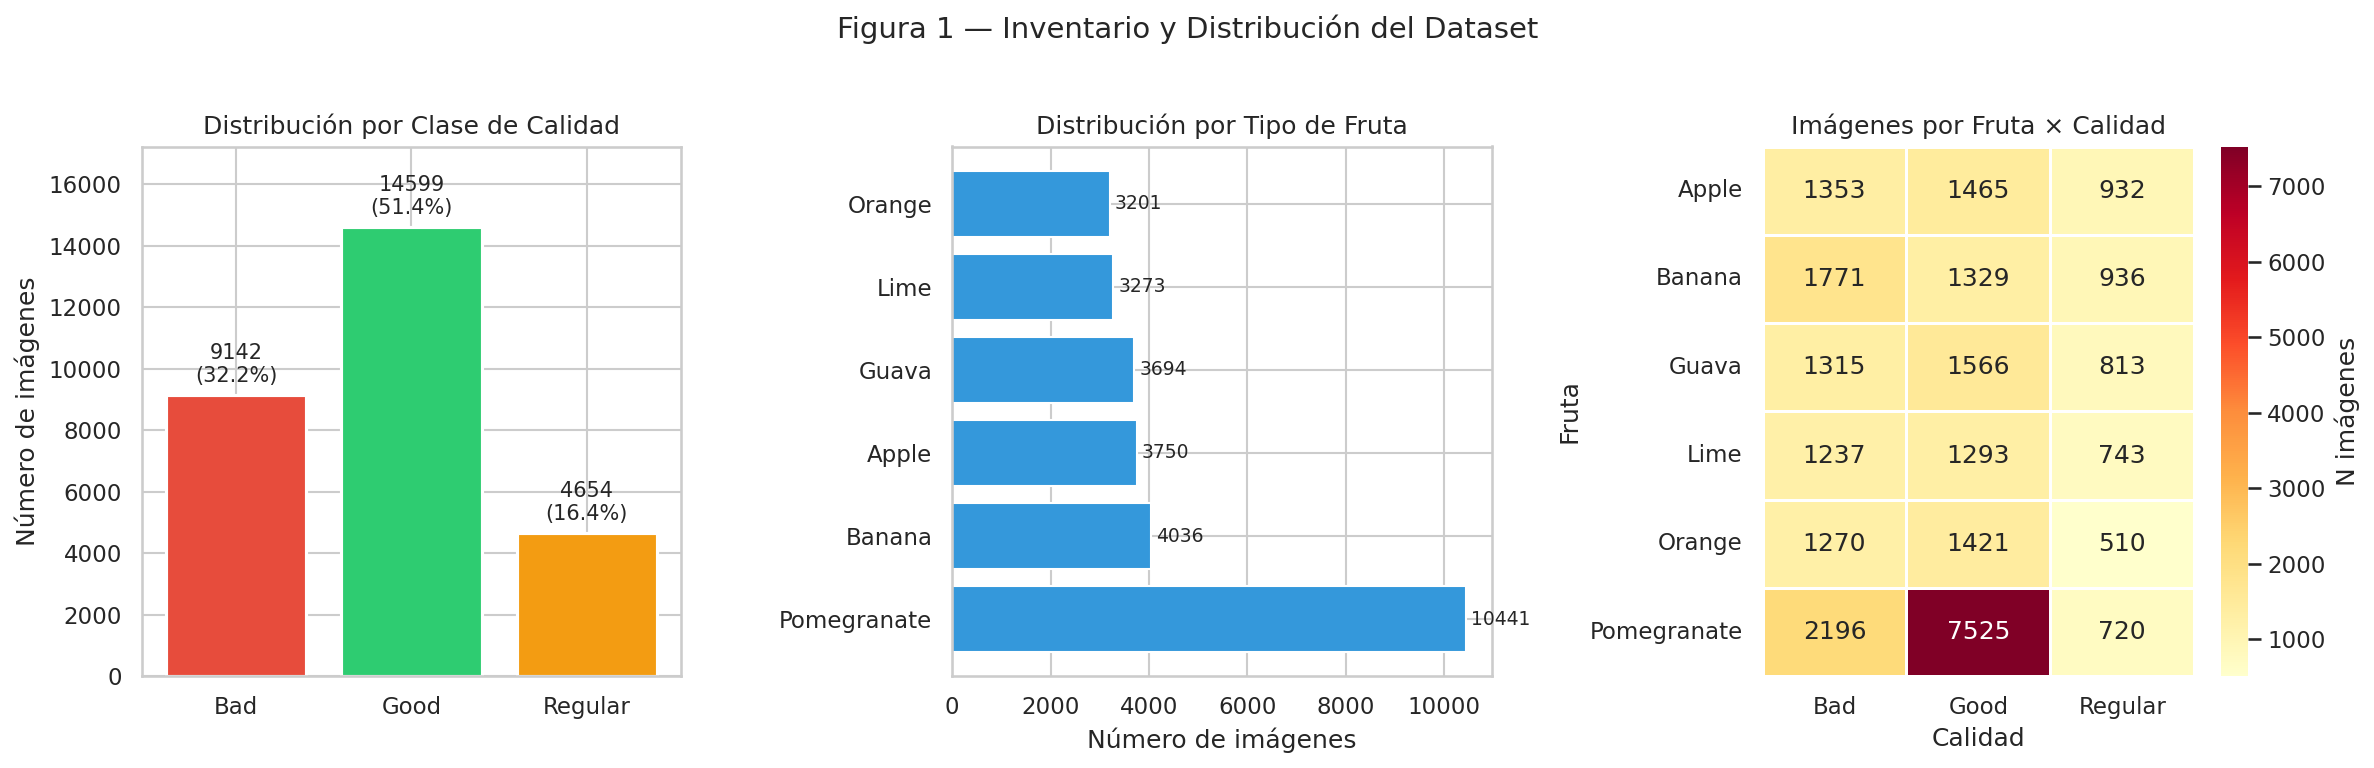


Imbalance Ratio (IR) = max/min = 14599/4654 = 3.14
IR > 1.5 → se recomienda usar class_weight="balanced" o técnicas de oversampling.
Desbalanceo severo (IR > 3.0): considerar oversampling o aumentar datos.


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── 2.1 Distribución por calidad
quality_counts = df['quality'].value_counts().reindex(CLASS_ORDER, fill_value=0)
colors = [QUALITY_COLORS[q] for q in quality_counts.index]
bars = axes[0].bar(quality_counts.index, quality_counts.values,
                   color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribución por Clase de Calidad')
axes[0].set_ylabel('Número de imágenes')

for bar, val in zip(bars, quality_counts.values):
    pct = (val / len(df) * 100) if len(df) > 0 else 0
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        max(val, 0) + max(quality_counts.max(), 1) * 0.02,
        f'{val}\n({pct:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=10
    )
axes[0].set_ylim(0, max(quality_counts.max() * 1.18, 1))

# ── 2.2 Distribución por fruta
fruit_counts = df['fruit'].value_counts()
axes[1].barh(fruit_counts.index, fruit_counts.values, color='#3498db', edgecolor='white')
axes[1].set_title('Distribución por Tipo de Fruta')
axes[1].set_xlabel('Número de imágenes')
for i, val in enumerate(fruit_counts.values):
    axes[1].text(val + max(fruit_counts.max(), 1) * 0.01, i, str(val), va='center', fontsize=9)

# ── 2.3 Heatmap fruta × calidad
cross = pd.crosstab(df['fruit'], df['quality']).reindex(columns=CLASS_ORDER, fill_value=0)
sns.heatmap(
    cross,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    ax=axes[2],
    linewidths=0.5,
    cbar_kws={'label': 'N imágenes'}
)
axes[2].set_title('Imágenes por Fruta × Calidad')
axes[2].set_xlabel('Calidad')
axes[2].set_ylabel('Fruta')

plt.suptitle('Figura 1 — Inventario y Distribución del Dataset', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig1_distribucion_clases.pdf', bbox_inches='tight')
plt.show()

# ── Indicador de desbalanceo: Imbalance Ratio
missing_classes = quality_counts[quality_counts == 0].index.tolist()
nonzero_counts = quality_counts[quality_counts > 0]

if missing_classes:
    ir = np.inf
    ir_text = (
        f'IR no calculable de forma válida porque faltan imágenes en: {missing_classes}. '
        'No se recomienda entrenar hasta corregir esas clases.'
    )
    print('\n' + ir_text)
elif len(nonzero_counts) > 0:
    q_max = nonzero_counts.max()
    q_min = nonzero_counts.min()
    ir = q_max / q_min

    print(f'\nImbalance Ratio (IR) = max/min = {q_max}/{q_min} = {ir:.2f}')
    print('IR > 1.5 → se recomienda usar class_weight="balanced" o técnicas de oversampling.')

    if ir <= 1.5:
        ir_text = 'Dataset relativamente balanceado (IR ≤ 1.5).'
    elif ir <= 3.0:
        ir_text = 'Desbalanceo moderado (1.5 < IR ≤ 3.0): se recomienda usar class_weight.'
    else:
        ir_text = 'Desbalanceo severo (IR > 3.0): considerar oversampling o aumentar datos.'
    print(ir_text)
else:
    ir = np.nan
    ir_text = 'No se pudo calcular IR porque no hay conteos válidos.'
    print(ir_text)


**Qué observar.** El valor de IR calculado indica el grado de desbalanceo real del dataset. Si la clase Regular tiene menos imágenes (lo esperable en este punto, dado que se está construyendo), el IR reflejará ese déficit y justificará directamente la recolección adicional de imágenes y la estrategia de `class_weight` que se usará durante el entrenamiento. El heatmap fruta × calidad permite además detectar si alguna fruta específica está subrepresentada en alguna clase, lo que podría crear sesgos del tipo "el modelo aprendió la fruta, no la calidad".


---
## 3. Variabilidad de dimensiones

Los modelos de machine learning y CNN requieren que todas las imágenes de entrada tengan el mismo tamaño. Antes de aplicar el reescalado, se analiza la distribución de dimensiones originales para dos propósitos: verificar si las imágenes del dataset son homogéneas (como ocurre en datasets de Kaggle bien curados) y confirmar que el tamaño de salida elegido (224×224 px) no implica una pérdida de información excesiva para la mayoría de las imágenes. El análisis se realiza sobre una muestra de hasta 500 imágenes para evitar tiempos de lectura elevados.


Leyendo dimensiones:   0%|          | 0/500 [00:00<?, ?it/s]

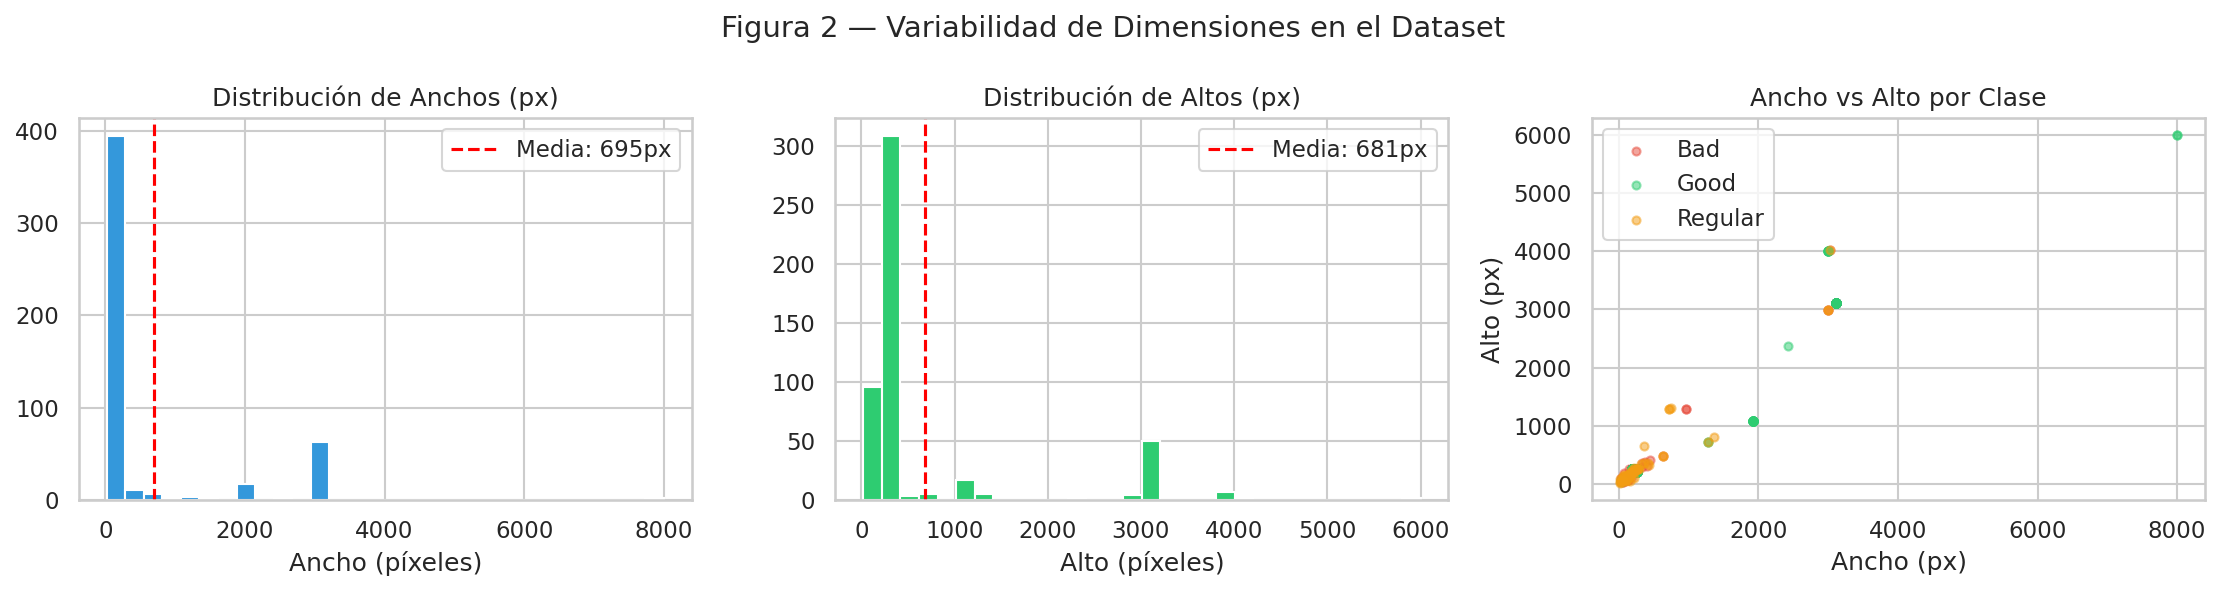


Resumen de dimensiones (muestra n=500):
       height   width  aspect_ratio
count   500.0   500.0         500.0
mean    680.6   694.7           1.0
std    1066.0  1089.4           0.3
min      19.0    17.0           0.3
25%     256.0   192.0           1.0
50%     256.0   256.0           1.0
75%     256.0   256.0           1.0
max    6000.0  8000.0           3.5


In [4]:
# ── Leer dimensiones de una muestra (hasta 500 imágenes para velocidad)
sample = df.sample(min(500, len(df)), random_state=42)
heights, widths, channels = [], [], []

for _, row in tqdm(sample.iterrows(), total=len(sample), desc='Leyendo dimensiones'):
    try:
        img = cv2.imread(row['path'])
        if img is not None:
            h, w, c = img.shape
            heights.append(h)
            widths.append(w)
            channels.append(c)
    except Exception:
        pass

sample = sample.iloc[:len(heights)].copy()
sample['height']   = heights
sample['width']    = widths
sample['channels'] = channels
sample['aspect_ratio'] = sample['width'] / sample['height']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histograma de anchos
axes[0].hist(widths, bins=30, color='#3498db', edgecolor='white')
axes[0].set_title('Distribución de Anchos (px)')
axes[0].set_xlabel('Ancho (píxeles)')
axes[0].axvline(np.mean(widths), color='red', linestyle='--', label=f'Media: {np.mean(widths):.0f}px')
axes[0].legend()

# Histograma de altos
axes[1].hist(heights, bins=30, color='#2ecc71', edgecolor='white')
axes[1].set_title('Distribución de Altos (px)')
axes[1].set_xlabel('Alto (píxeles)')
axes[1].axvline(np.mean(heights), color='red', linestyle='--', label=f'Media: {np.mean(heights):.0f}px')
axes[1].legend()

# Scatter ancho vs alto (coloreado por calidad)
for quality, grp in sample.groupby('quality'):
    axes[2].scatter(grp['width'], grp['height'],
                    alpha=0.5, s=15, label=quality,
                    color=QUALITY_COLORS.get(quality, 'gray'))
axes[2].set_title('Ancho vs Alto por Clase')
axes[2].set_xlabel('Ancho (px)')
axes[2].set_ylabel('Alto (px)')
axes[2].legend()

plt.suptitle('Figura 2 — Variabilidad de Dimensiones en el Dataset', fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig2_dimensiones.pdf', bbox_inches='tight')
plt.show()

print(f'\nResumen de dimensiones (muestra n={len(sample)}):')
print(sample[['height','width','aspect_ratio']].describe().round(1).to_string())

---
## 4. Análisis del espacio de color (RGB)

El color es la característica visual más inmediata para distinguir frutas en buen estado de frutas deterioradas. Una manzana Bad, por ejemplo, tiende a tener zonas oscuras o pardas que se manifiestan como un desplazamiento en los canales R y G. Para verificar si esta separación es estadísticamente observable, se calcula el histograma promedio de cada canal RGB por clase:

$$\bar{h}_c(k) = \frac{1}{N} \sum_{i=1}^{N} h_{c,i}(k), \quad k \in [0, 255]$$

donde $h_{c,i}(k)$ es el histograma normalizado del canal $c$ en la imagen $i$, y $N$ es el número de imágenes de esa clase. Si las curvas promedio de Bad, Good y Regular se solapan completamente, el modelo necesitará apoyarse en textura y forma además del color.


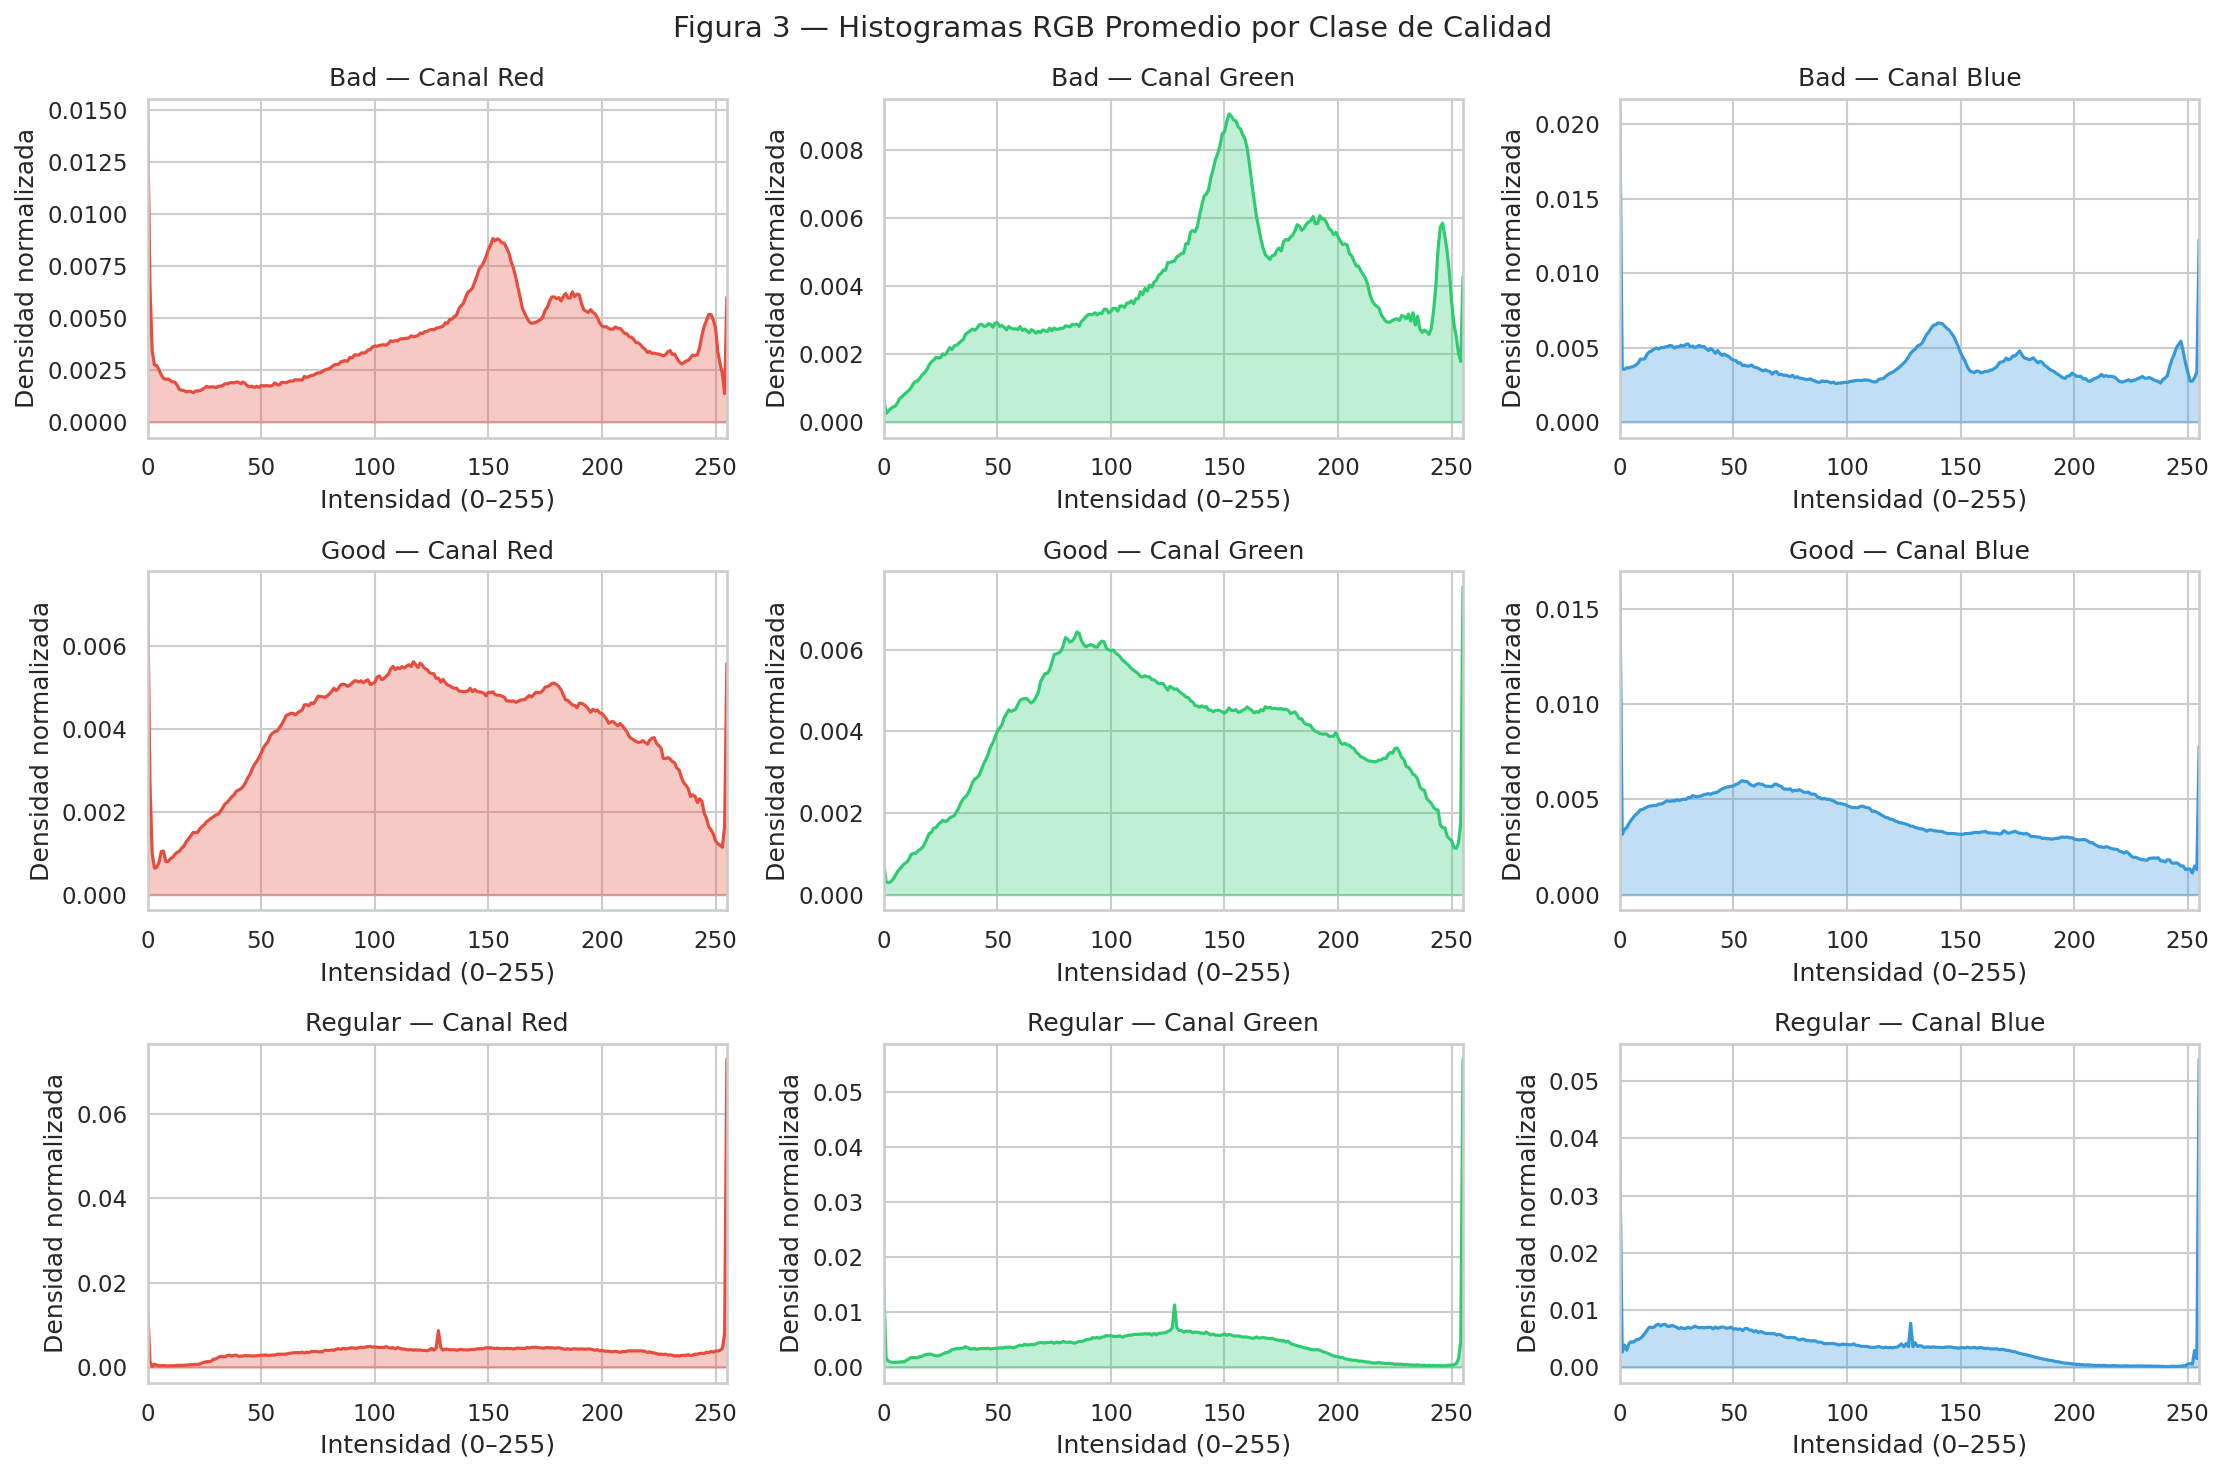

Los histogramas RGB permiten observar si las clases tienen patrones de color diferenciables.
Si dos clases presentan histogramas muy similares, el modelo necesitará apoyarse en textura, forma u otras características.


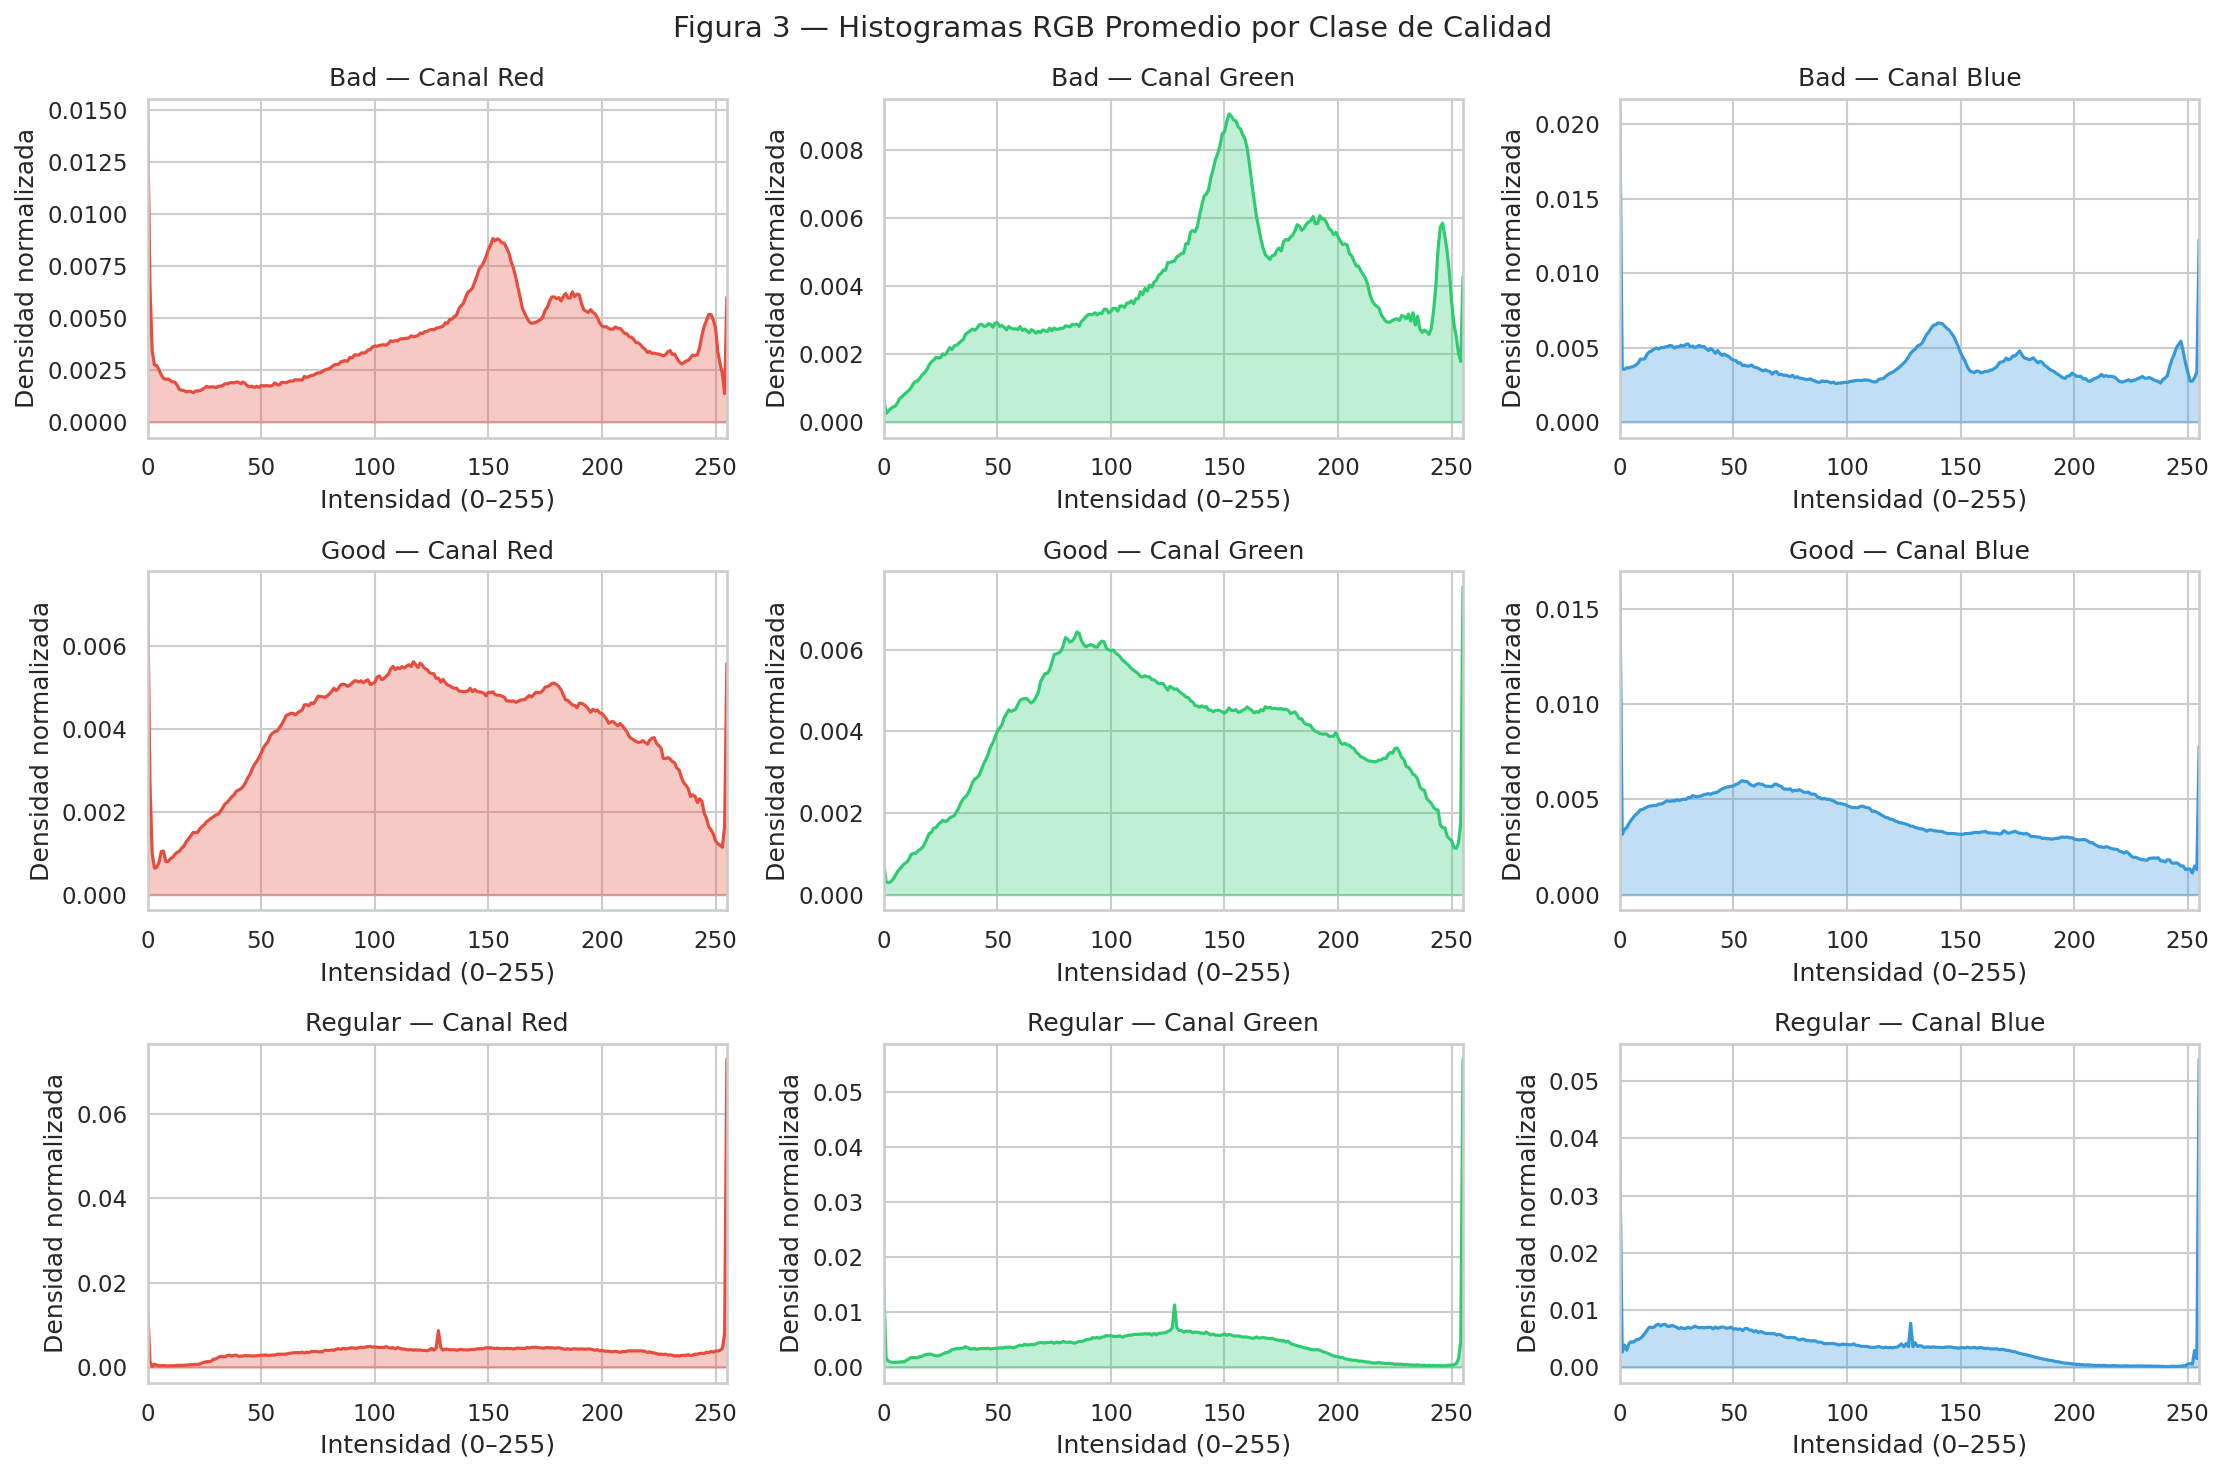

Los histogramas RGB permiten observar si las clases tienen patrones de color diferenciables.
Si dos clases presentan histogramas muy similares, el modelo necesitará apoyarse en textura, forma u otras características.


In [5]:
def mean_rgb_histogram(paths: list, n: int = 150) -> np.ndarray:
    """Calcula histograma RGB promedio sobre n imágenes de una lista de rutas."""
    hist_sum = np.zeros((3, 256), dtype=np.float64)
    count = 0

    for p in paths[:n]:
        try:
            img = cv2.imread(p)
            if img is None:
                continue

            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            for c in range(3):
                hist = cv2.calcHist([img_rgb], [c], None, [256], [0, 256]).flatten()
                hist_sum[c] += hist / max(hist.sum(), 1)

            count += 1

        except Exception:
            pass

    return hist_sum / max(count, 1)

channel_names = ['Red', 'Green', 'Blue']
channel_colors = ['#e74c3c', '#2ecc71', '#3498db']

fig, axes = plt.subplots(3, 3, figsize=(15, 10))

for row_i, quality in enumerate(CLASS_ORDER):
    paths = df[df['quality'] == quality]['path'].tolist()

    if len(paths) == 0:
        for col_j in range(3):
            ax = axes[row_i][col_j]
            ax.axis('off')
            ax.text(
                0.5, 0.5,
                f'Sin imágenes\npara {quality}',
                ha='center',
                va='center',
                fontsize=11
            )
        continue

    hists = mean_rgb_histogram(paths, n=200)

    for col_j, (ch_name, ch_color) in enumerate(zip(channel_names, channel_colors)):
        ax = axes[row_i][col_j]
        ax.plot(hists[col_j], color=ch_color, linewidth=1.5)
        ax.fill_between(range(256), hists[col_j], alpha=0.3, color=ch_color)
        ax.set_xlim(0, 255)
        ax.set_title(f'{quality} — Canal {ch_name}')
        ax.set_xlabel('Intensidad (0–255)')
        ax.set_ylabel('Densidad normalizada')

plt.suptitle('Figura 3 — Histogramas RGB Promedio por Clase de Calidad', fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig3_histogramas_rgb.pdf', bbox_inches='tight')
plt.show()

print('Los histogramas RGB permiten observar si las clases tienen patrones de color diferenciables.')
print('Si dos clases presentan histogramas muy similares, el modelo necesitará apoyarse en textura, forma u otras características.')
def mean_rgb_histogram(paths: list, n: int = 150) -> np.ndarray:
    """Calcula histograma RGB promedio sobre n imágenes de una lista de rutas."""
    hist_sum = np.zeros((3, 256), dtype=np.float64)
    count = 0

    for p in paths[:n]:
        try:
            img = cv2.imread(p)
            if img is None:
                continue

            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            for c in range(3):
                hist = cv2.calcHist([img_rgb], [c], None, [256], [0, 256]).flatten()
                hist_sum[c] += hist / max(hist.sum(), 1)

            count += 1

        except Exception:
            pass

    return hist_sum / max(count, 1)

channel_names = ['Red', 'Green', 'Blue']
channel_colors = ['#e74c3c', '#2ecc71', '#3498db']

fig, axes = plt.subplots(3, 3, figsize=(15, 10))

for row_i, quality in enumerate(CLASS_ORDER):
    paths = df[df['quality'] == quality]['path'].tolist()

    if len(paths) == 0:
        for col_j in range(3):
            ax = axes[row_i][col_j]
            ax.axis('off')
            ax.text(
                0.5, 0.5,
                f'Sin imágenes\npara {quality}',
                ha='center',
                va='center',
                fontsize=11
            )
        continue

    hists = mean_rgb_histogram(paths, n=200)

    for col_j, (ch_name, ch_color) in enumerate(zip(channel_names, channel_colors)):
        ax = axes[row_i][col_j]
        ax.plot(hists[col_j], color=ch_color, linewidth=1.5)
        ax.fill_between(range(256), hists[col_j], alpha=0.3, color=ch_color)
        ax.set_xlim(0, 255)
        ax.set_title(f'{quality} — Canal {ch_name}')
        ax.set_xlabel('Intensidad (0–255)')
        ax.set_ylabel('Densidad normalizada')

plt.suptitle('Figura 3 — Histogramas RGB Promedio por Clase de Calidad', fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig3_histogramas_rgb.pdf', bbox_inches='tight')
plt.show()

print('Los histogramas RGB permiten observar si las clases tienen patrones de color diferenciables.')
print('Si dos clases presentan histogramas muy similares, el modelo necesitará apoyarse en textura, forma u otras características.')


**Qué observar.** Diferencias en la forma o posición de los histogramas entre clases son evidencia directa de separabilidad en el espacio de color. En frutas con deterioro visible, es común ver en la clase Bad un desplazamiento hacia intensidades más bajas en el canal Green (pérdida de frescura) y picos en zonas oscuras del canal Red. Si las tres clases muestran histogramas prácticamente idénticos, eso indica que el color solo no discrimina bien y que las características de textura o forma aportadas por la CNN serán más relevantes que los descriptores de color usados por los modelos ML tradicionales.


---
## 5. Mosaico visual por clase

La inspección visual directa de muestras es irreemplazable. Errores de etiquetado, fondos no uniformes, frutas parcialmente cortadas, objetos extraños en la imagen o variaciones de iluminación extremas pueden no quedar evidentes en estadísticas numéricas pero sí son detectables con un mosaico. Se muestran 12 imágenes aleatorias por clase.


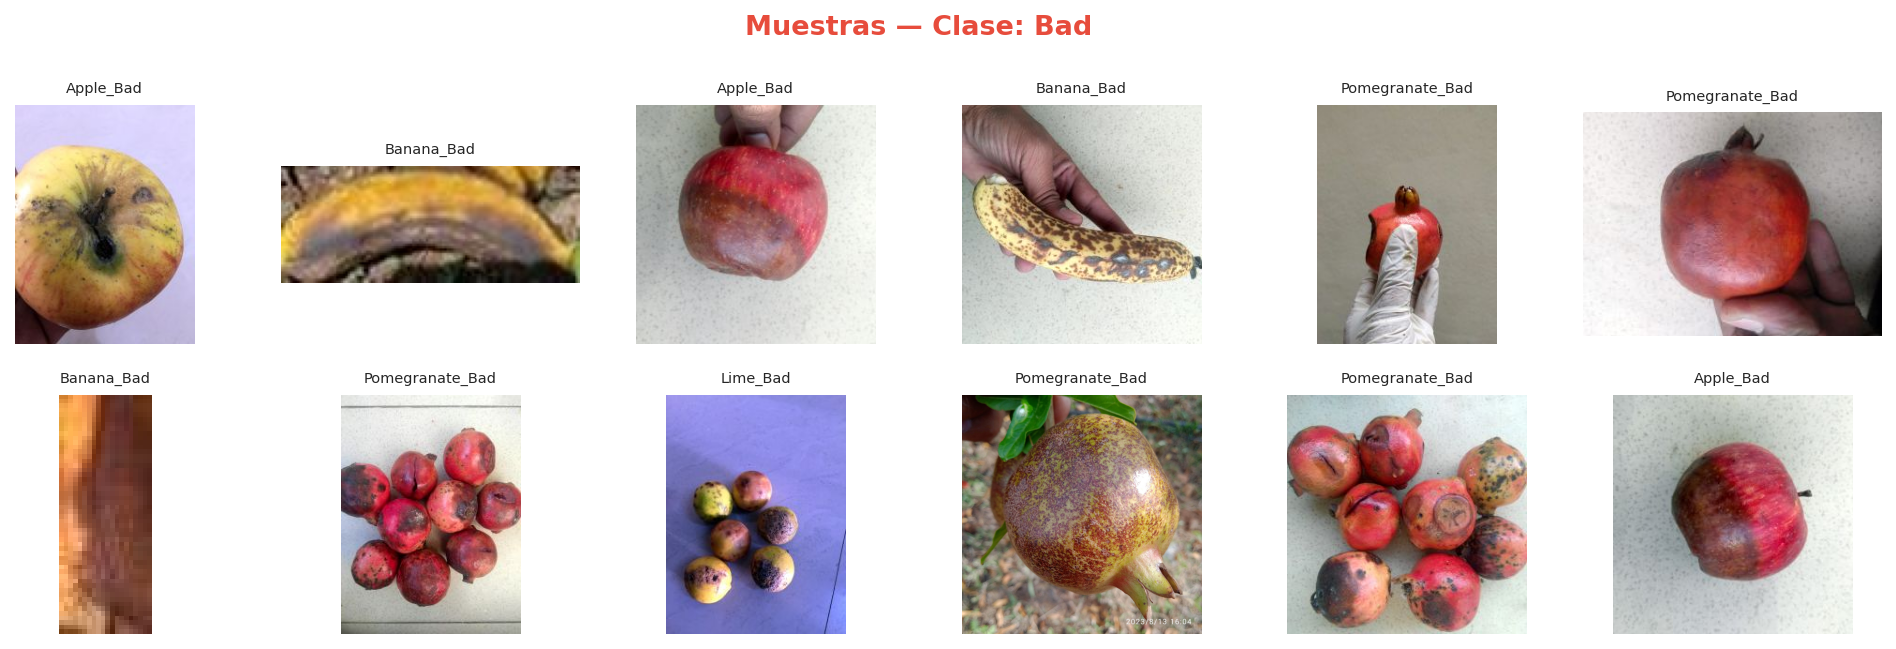

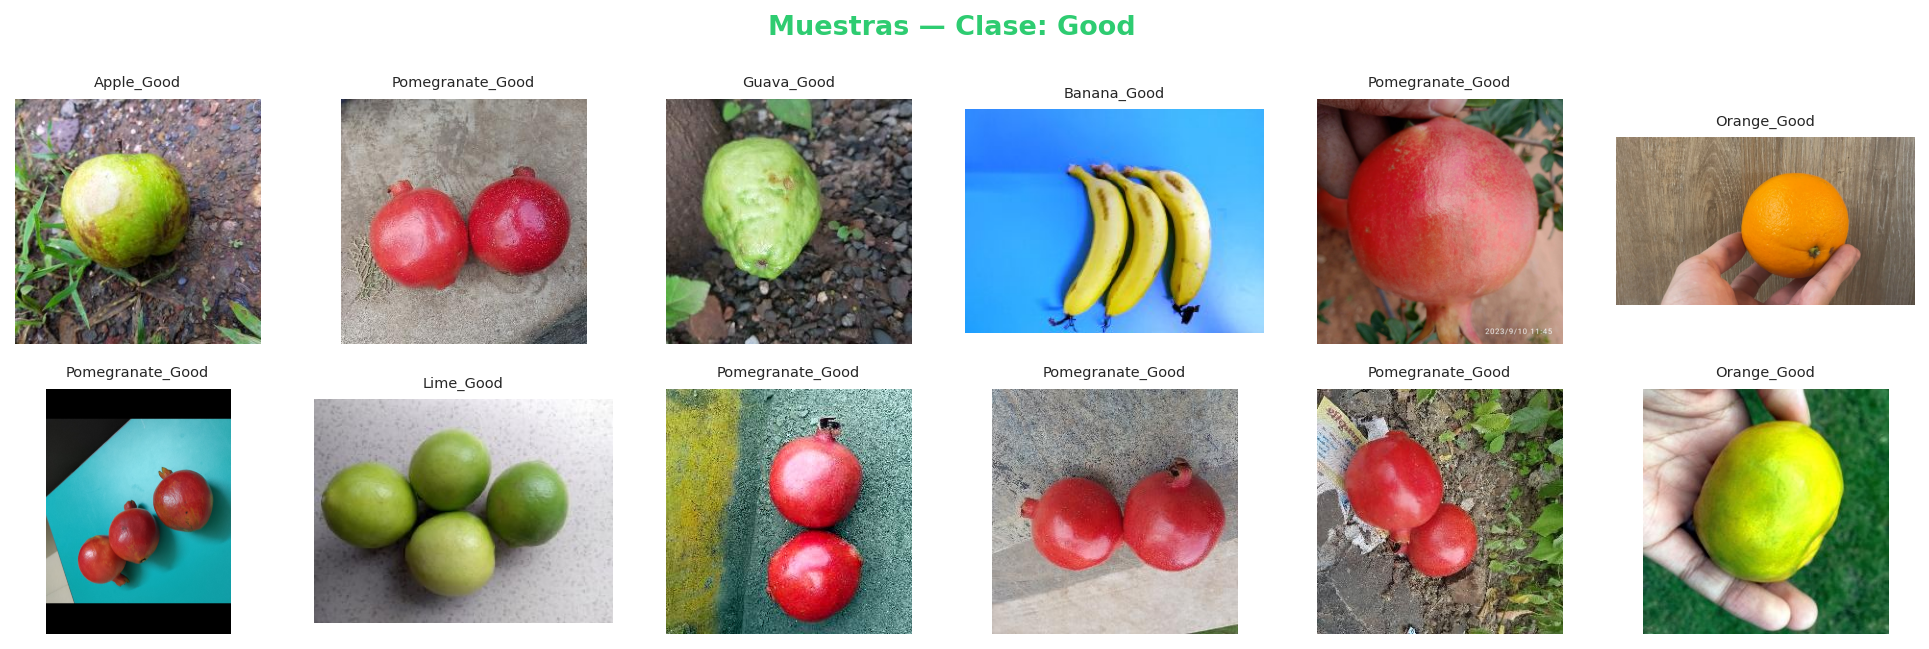

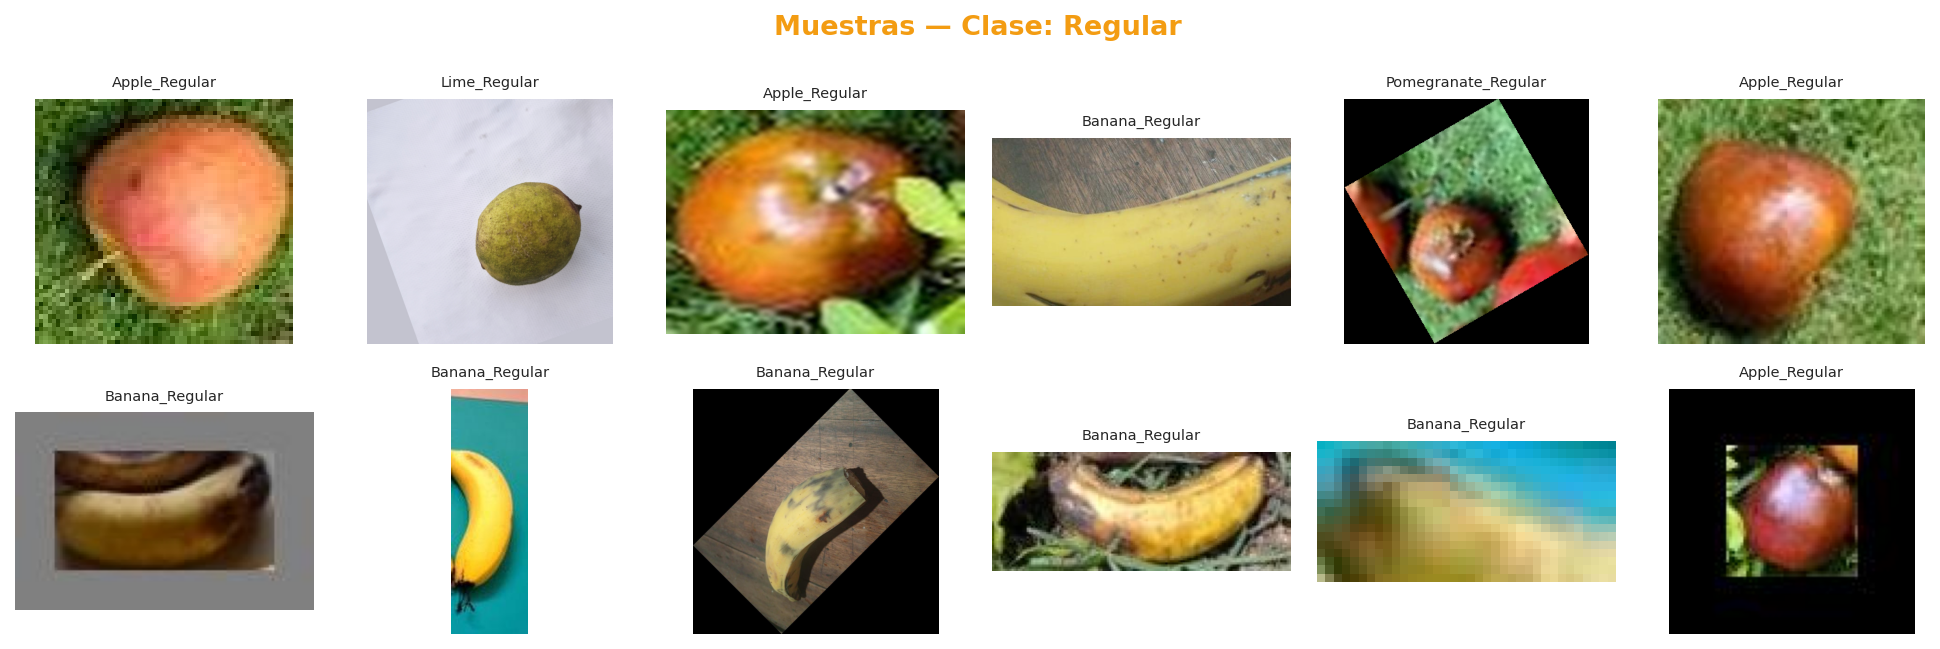

In [6]:
def show_mosaic(df_subset: pd.DataFrame, quality: str, n: int = 12, cols: int = 6):
    """Muestra un mosaico de n imágenes de muestra de una clase."""
    subset = df_subset[df_subset['quality'] == quality]

    if subset.empty:
        print(f'No hay imágenes para la clase {quality}. Se omite el mosaico.')
        return

    paths = subset['path'].sample(min(n, len(subset)), random_state=42).tolist()

    rows = max(1, math.ceil(len(paths) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.2, rows * 2.2))
    axes = np.array(axes).flatten()

    for i, p in enumerate(paths):
        img = cv2.imread(p)
        if img is not None:
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[i].imshow(img_rgb)

        axes[i].axis('off')
        axes[i].set_title(Path(p).parent.name, fontsize=7)

    for j in range(len(paths), len(axes)):
        axes[j].axis('off')

    color = QUALITY_COLORS.get(quality, 'gray')
    plt.suptitle(f'Muestras — Clase: {quality}', fontsize=13, color=color, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'fig4_mosaic_{quality.lower()}.pdf', bbox_inches='tight')
    plt.show()

for q in CLASS_ORDER:
    show_mosaic(df, q, n=12)


**Qué observar.** Revisar si las imágenes de Bad muestran claramente defectos visibles (manchas, golpes, podredumbre), si las de Good tienen aspecto uniforme y sin daños, y si las de Regular presentan condiciones intermedias coherentes. También verificar que los fondos sean lo suficientemente uniformes para que la remoción de fondo en `preprocess.py` funcione correctamente. Si se detectan imágenes mal etiquetadas o con problemas graves, deben corregirse antes del entrenamiento.


---
## 6. Estimación de tamaño relativo

El proyecto requiere que el sistema estime si la fruta es pequeña, mediana o grande. Para hacerlo de forma objetiva, se usa el `area_ratio`: la fracción de píxeles de la imagen que pertenecen a la fruta, obtenida a partir de una máscara HSV por saturación.

$$\text{area\_ratio} = \frac{N_{\text{fruta}}}{H \times W}$$

donde $N_{\text{fruta}}$ es el número de píxeles con saturación $S > 30$ en el espacio HSV. La clasificación de tamaño usa umbrales fijos: `small` si area_ratio < 0.20, `medium` si < 0.50, y `large` en caso contrario. Adicionalmente, se calcula el diámetro equivalente normalizado como el diámetro de un círculo con la misma área:

$$d_{\text{norm}} = \frac{\sqrt{4 \cdot N_{\text{fruta}} / \pi}}{\max(H, W)}$$


Calculando áreas:   0%|          | 0/500 [00:00<?, ?it/s]

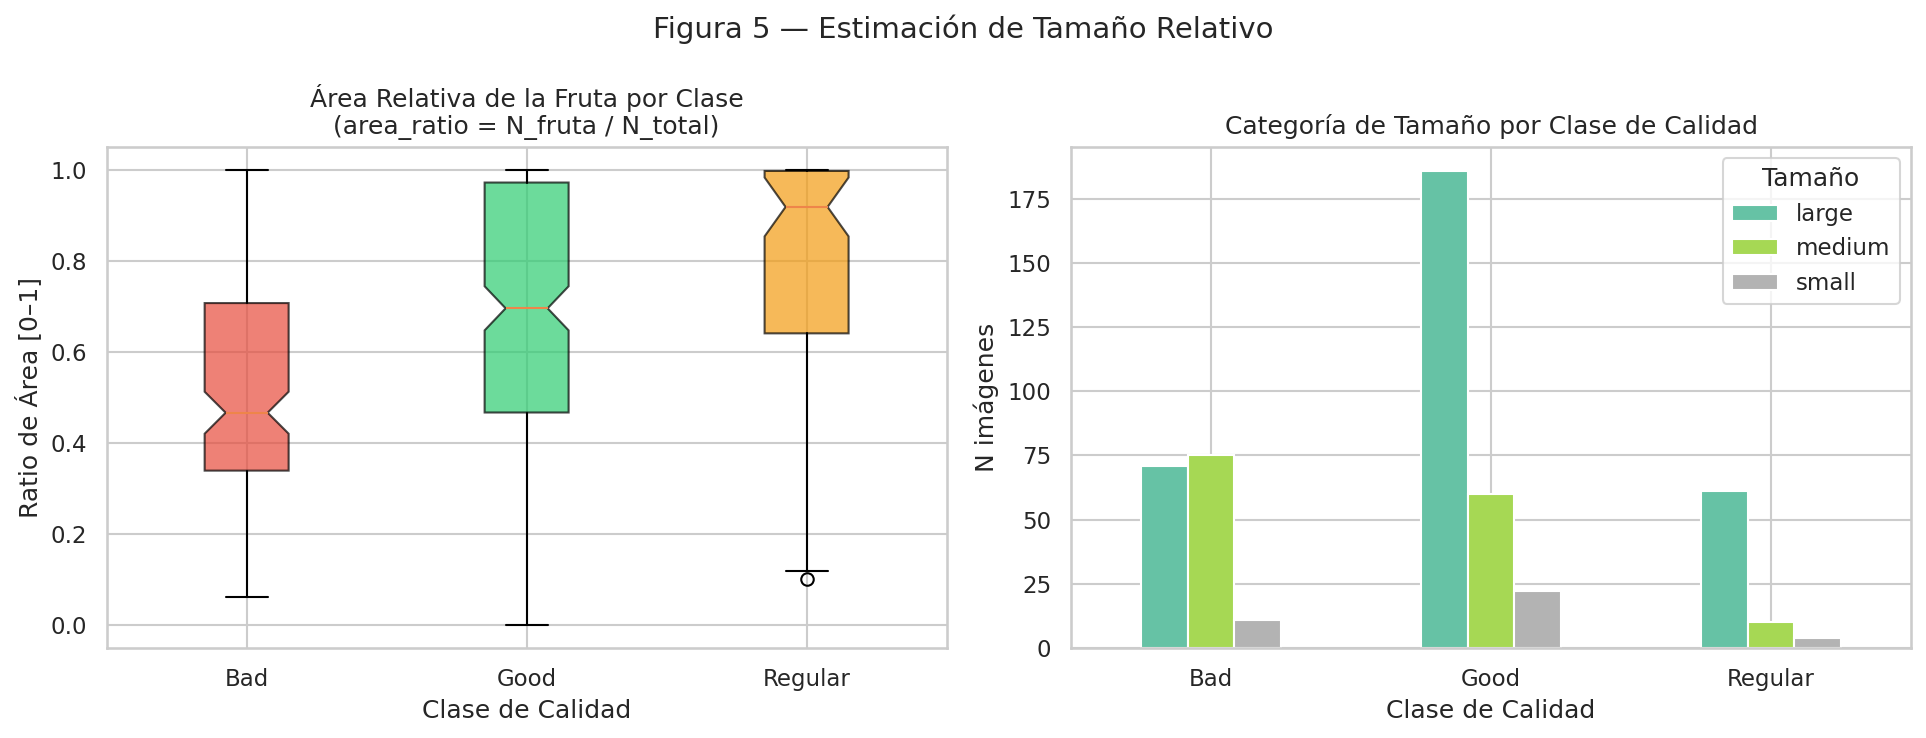

         count   mean    std    min    25%    50%    75%    max
quality                                                        
Bad      157.0  0.541  0.266  0.062  0.339  0.466  0.707  0.998
Good     268.0  0.670  0.303  0.000  0.467  0.695  0.972  1.000
Regular   75.0  0.802  0.253  0.101  0.640  0.918  0.997  1.000


In [7]:
def estimate_area_ratio(img_bgr: np.ndarray) -> float:
    """
    Estima el área relativa de la fruta mediante máscara de saturación HSV.
    
    Fórmula: area_ratio = N_pixels_fruta / (H × W)
    
    Donde N_pixels_fruta = suma de pixeles con saturación S > 30 en HSV.
    """
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    mask = (hsv[:, :, 1] > 30).astype(np.uint8)
    total = img_bgr.shape[0] * img_bgr.shape[1]
    return float(mask.sum()) / total

# Calcular para muestra
area_records = []
for _, row in tqdm(sample.iterrows(), total=len(sample), desc='Calculando áreas'):
    try:
        img = cv2.imread(row['path'])
        if img is not None:
            ratio = estimate_area_ratio(img)
            area_records.append({'quality': row['quality'], 'fruit': row['fruit'], 'area_ratio': ratio})
    except Exception:
        pass

df_area = pd.DataFrame(area_records)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Boxplot area_ratio por calidad
data_by_quality = [df_area[df_area['quality'] == q]['area_ratio'].values
                   for q in ['Bad', 'Good', 'Regular']]
bp = axes[0].boxplot(data_by_quality, labels=['Bad', 'Good', 'Regular'],
                     patch_artist=True, notch=True)
for patch, q in zip(bp['boxes'], ['Bad', 'Good', 'Regular']):
    patch.set_facecolor(QUALITY_COLORS[q])
    patch.set_alpha(0.7)
axes[0].set_title('Área Relativa de la Fruta por Clase\n(area_ratio = N_fruta / N_total)')
axes[0].set_ylabel('Ratio de Área [0–1]')
axes[0].set_xlabel('Clase de Calidad')

# Categorías de tamaño
def cat_size(ar):
    if ar < 0.20: return 'small'
    elif ar < 0.50: return 'medium'
    else: return 'large'

df_area['size_cat'] = df_area['area_ratio'].apply(cat_size)
size_cross = pd.crosstab(df_area['quality'], df_area['size_cat'])
size_cross.plot(kind='bar', ax=axes[1], colormap='Set2', edgecolor='white')
axes[1].set_title('Categoría de Tamaño por Clase de Calidad')
axes[1].set_xlabel('Clase de Calidad')
axes[1].set_ylabel('N imágenes')
axes[1].legend(title='Tamaño')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Figura 5 — Estimación de Tamaño Relativo', fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig5_size_estimation.pdf', bbox_inches='tight')
plt.show()
print(df_area.groupby('quality')['area_ratio'].describe().round(3))

**Qué observar.** Si el `area_ratio` varía mucho dentro de una misma clase, significa que las imágenes tienen distintos niveles de zoom o encuadre. Esto no es un problema para los modelos CNN (que aprenden invarianzas), pero sí puede afectar a KNN o SVM si se usan directamente los píxeles como características. También conviene verificar que la distribución de tamaños sea similar entre clases: si Bad tiene frutas sistemáticamente más pequeñas que Good, el modelo podría aprender a clasificar por tamaño en lugar de por calidad.


---
## 7. Validación del pipeline de preprocesamiento

Antes de procesar el dataset completo, se verifica visualmente que cada etapa del pipeline definido en `preprocess.py` produce el resultado esperado sobre una imagen de muestra. Las cuatro etapas son: lectura de la imagen original, remoción de fondo por umbralización HSV, reescalado a 224×224 px con padding simétrico blanco, y normalización Min-Max (mostrada únicamente como visualización; los valores float se aplican durante el entrenamiento, no se guardan como JPG).


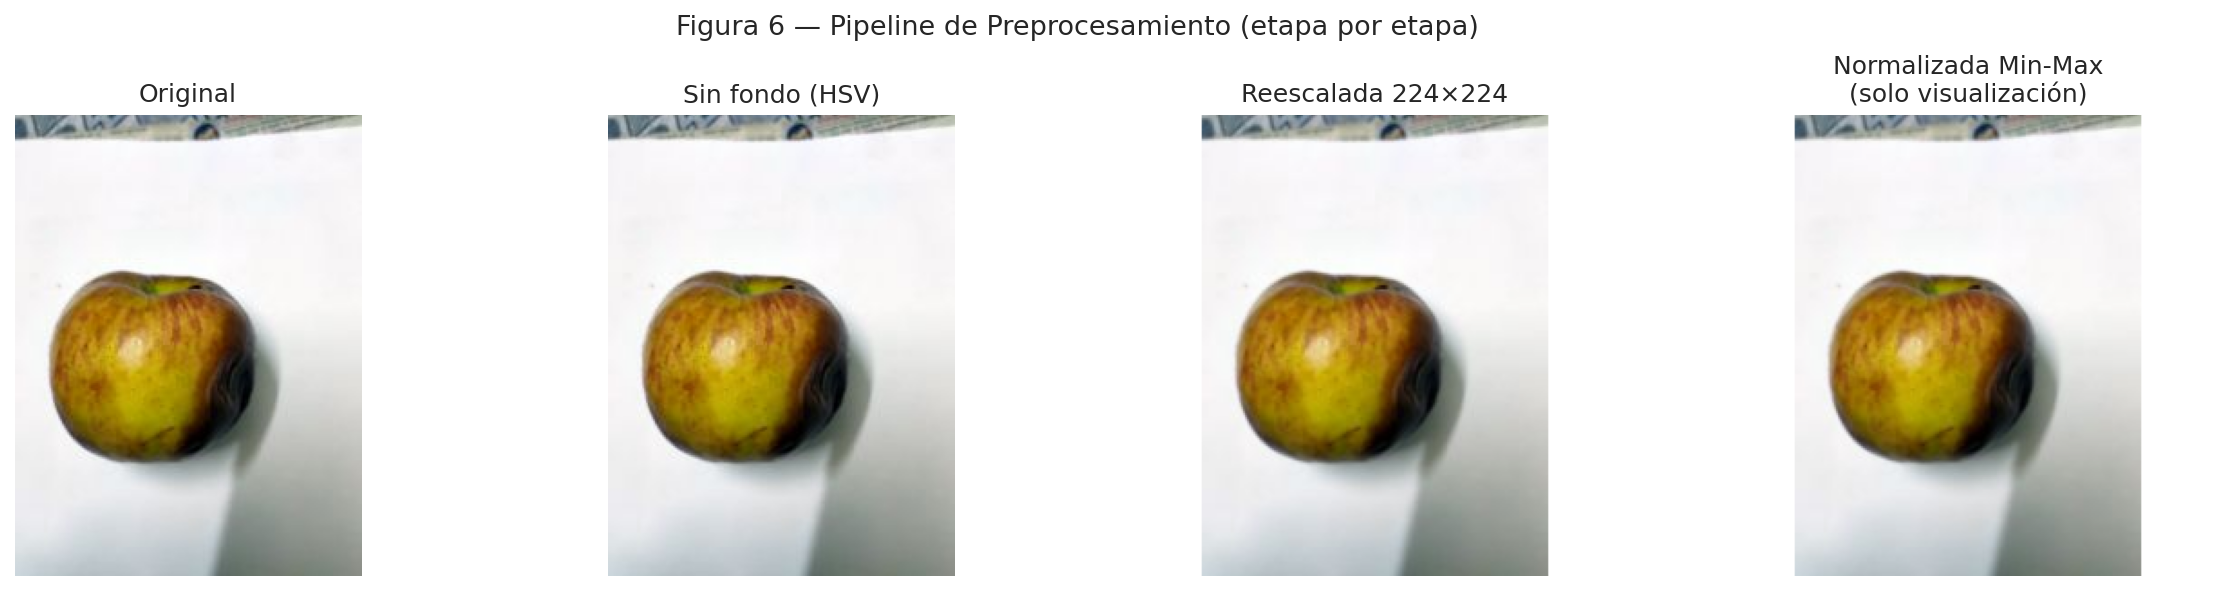

In [8]:
import sys
sys.path.insert(0, str(Path('../src/data_processing')))

try:
    from preprocess import remove_background_hsv, resize_with_padding, normalize_minmax

    # Tomar una imagen de muestra
    sample_path = df.sample(1, random_state=7).iloc[0]['path']
    img_raw = cv2.imread(sample_path)

    img_nobg    = remove_background_hsv(img_raw)
    img_resized = resize_with_padding(img_nobg, 224)
    img_norm    = normalize_minmax(img_resized)

    # Convertir img_norm a uint8 únicamente para visualización.
    # La normalización real debe aplicarse durante entrenamiento o guardarse como array,
    # no como JPG, porque JPG no conserva valores float [0,1].
    img_norm_vis = (img_norm * 255).clip(0, 255).astype(np.uint8)

    stages = [
        ('Original', img_raw),
        ('Sin fondo (HSV)', img_nobg),
        ('Reescalada 224×224', img_resized),
        ('Normalizada Min-Max\n(solo visualización)', img_norm_vis),
    ]

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    for ax, (title, img) in zip(axes, stages):
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
        ax.set_title(title)
        ax.axis('off')
        h, w = img.shape[:2]
        ax.set_xlabel(f'{w}×{h}px')

    plt.suptitle('Figura 6 — Pipeline de Preprocesamiento (etapa por etapa)', fontsize=13)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'fig6_pipeline_stages.pdf', bbox_inches='tight')
    plt.show()

except ImportError as e:
    print(f'No se pudo importar preprocess.py: {e}')
    print('Asegúrate de que src/data_processing/preprocess.py exista.')
except Exception as e:
    print(f'Error durante la validación del preprocesamiento: {e}')


**Qué verificar.** La imagen sin fondo debe mostrar la fruta aislada sobre blanco sin que se hayan eliminado partes de la fruta misma (un umbral de saturación muy agresivo puede recortar zonas claras de la piel). El padding debe ser simétrico y no distorsionar las proporciones. Si se detectan problemas — por ejemplo, frutas con piel muy clara que se confunden con el fondo — se deben ajustar los parámetros `S_THRESH` y `V_THRESH` en `preprocess.py` antes de procesar el dataset completo.


---
## 8. Verificación del dataset procesado

Una vez ejecutado `preprocess.py`, se inspecciona el archivo `metadata.csv` generado en `data/processed/`. Este archivo es la única fuente de verdad sobre qué imágenes entran al entrenamiento: contiene las rutas, etiquetas numéricas, indicador de augmentation y métricas de tamaño de cada imagen. La verificación garantiza que las tres clases están representadas y que el aumento de datos se aplicó de forma uniforme.


Dataset procesado: 141975 registros totales
Columnas: ['file', 'label', 'quality', 'fruit', 'augmented', 'aug_index', 'size_category', 'area_ratio', 'diameter_norm']

Validación OK: metadata.csv contiene las columnas esperadas.


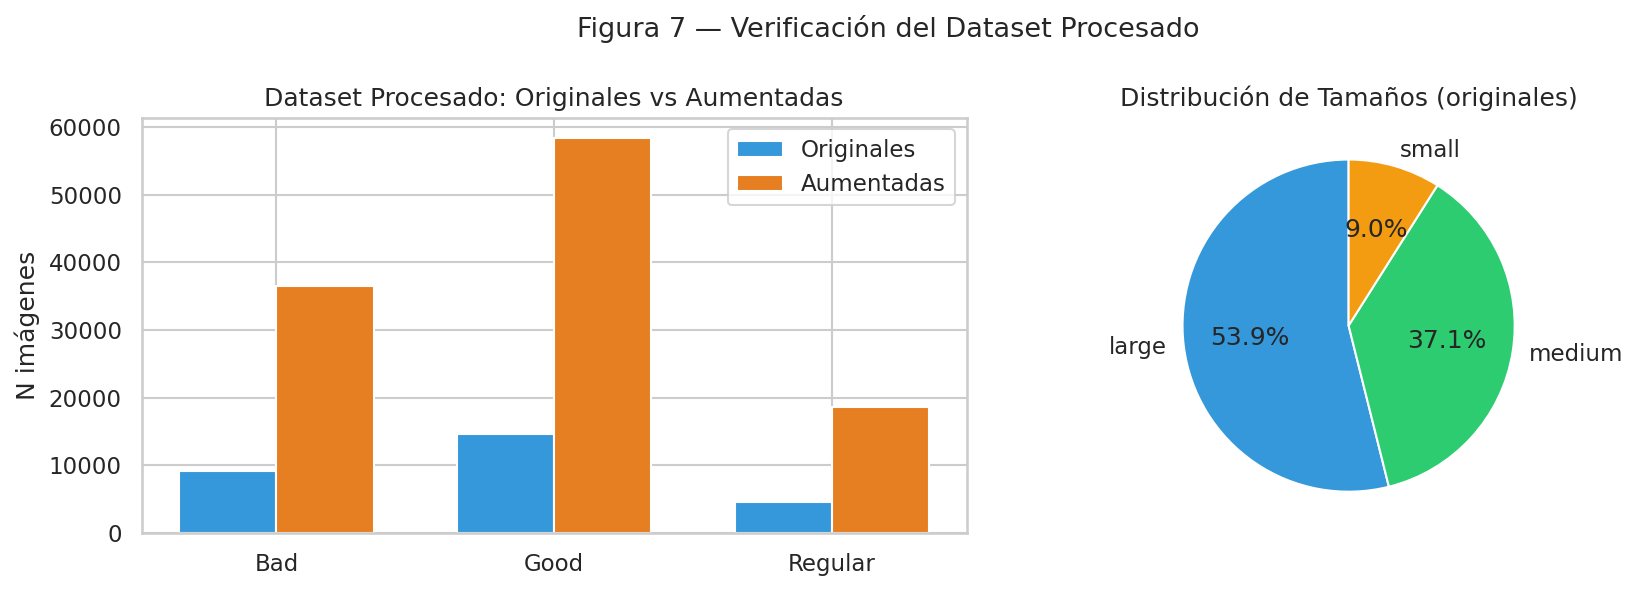

augmented,0,1
quality,,
Bad,9142,36568
Good,14599,58396
Regular,4654,18616



Validación OK: el dataset procesado contiene las tres clases oficiales.


In [9]:
meta_path = PROCESSED_DIR / 'metadata.csv'

if meta_path.exists():
    df_meta = pd.read_csv(meta_path)
    print(f'Dataset procesado: {len(df_meta)} registros totales')
    print(f'Columnas: {df_meta.columns.tolist()}')
    print()

    expected_columns = {
        'file', 'label', 'quality', 'fruit',
        'augmented', 'aug_index',
        'size_category', 'area_ratio', 'diameter_norm'
    }
    missing_columns = sorted(expected_columns - set(df_meta.columns))

    if missing_columns:
        print('ALERTA: faltan columnas esperadas en metadata.csv:', missing_columns)
    else:
        print('Validación OK: metadata.csv contiene las columnas esperadas.')

    orig = df_meta[df_meta['augmented'] == 0]
    aug  = df_meta[df_meta['augmented'] == 1]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Originales vs aumentados por clase
    orig_counts = orig['quality'].value_counts().reindex(CLASS_ORDER, fill_value=0)
    aug_counts  = aug['quality'].value_counts().reindex(CLASS_ORDER, fill_value=0)

    x = np.arange(len(CLASS_ORDER))
    width = 0.35

    axes[0].bar(x - width/2, orig_counts.values, width, label='Originales', color='#3498db')
    axes[0].bar(x + width/2, aug_counts.values,  width, label='Aumentadas', color='#e67e22')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(CLASS_ORDER)
    axes[0].set_title('Dataset Procesado: Originales vs Aumentadas')
    axes[0].set_ylabel('N imágenes')
    axes[0].legend()

    # Categorías de tamaño en el dataset final
    if 'size_category' in orig.columns and not orig.empty:
        size_counts = orig['size_category'].value_counts()
        axes[1].pie(
            size_counts.values,
            labels=size_counts.index,
            autopct='%1.1f%%',
            startangle=90,
            colors=['#3498db', '#2ecc71', '#f39c12'][:len(size_counts)]
        )
        axes[1].set_title('Distribución de Tamaños (originales)')
    else:
        axes[1].axis('off')
        axes[1].text(0.5, 0.5, 'Sin datos de tamaño', ha='center', va='center')

    plt.suptitle('Figura 7 — Verificación del Dataset Procesado', fontsize=13)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'fig7_processed_dataset.pdf', bbox_inches='tight')
    plt.show()

    processed_summary = df_meta.groupby(['quality','augmented']).size().unstack(fill_value=0)
    processed_summary = processed_summary.reindex(index=CLASS_ORDER, fill_value=0)
    display(processed_summary)

    missing_processed_classes = processed_summary[processed_summary.sum(axis=1) == 0].index.tolist()
    if missing_processed_classes:
        print('\nALERTA: el dataset procesado no contiene registros para:', missing_processed_classes)
        print('Vuelve a ejecutar preprocess.py después de corregir data/raw/.')
    else:
        print('\nValidación OK: el dataset procesado contiene las tres clases oficiales.')

else:
    print(f'metadata.csv no encontrado en {meta_path}')
    print('Primero ejecuta desde la raíz del proyecto:')
    print('python src/data_processing/preprocess.py')


**Qué verificar.** El conteo de imágenes originales vs. aumentadas debe ser proporcional entre clases; si Bad tiene cuatro veces más aumentos que Regular, el desbalanceo del raw se amplifica en lugar de reducirse. También se comprueba que `metadata.csv` contiene todas las columnas esperadas, ya que los notebooks de entrenamiento (02 y 03) leen directamente este archivo para construir los conjuntos train/val/test.


---
## 9. Resumen para el informe técnico

Los siguientes valores se obtienen automáticamente del análisis y están listos para transcribirse a la sección **Comprensión de los Datos** del informe final (CRISP-DM, fase 2).


In [10]:
print('=' * 65)
print('  RESUMEN EDA — Fruit Quality Classification')
print('  Para el informe técnico (Sección: Comprensión de Datos)')
print('=' * 65)

quality_counts_summary = df['quality'].value_counts().reindex(CLASS_ORDER, fill_value=0)
fruit_list = ", ".join(sorted(df["fruit"].unique()))

print(f'\nTotal de imágenes crudas        : {len(df)}')
print(f'Tipos de fruta                  : {df["fruit"].nunique()} ({fruit_list})')
print('Clases de calidad               : Bad (0), Good (1), Regular (2)')
print()

for q in CLASS_ORDER:
    n = int(quality_counts_summary[q])
    pct = n / len(df) * 100 if len(df) else 0
    print(f'  {q:10s}: {n:5d} imágenes ({pct:.1f}%)')

# Estado del desbalanceo
missing_classes = quality_counts_summary[quality_counts_summary == 0].index.tolist()
if missing_classes:
    ir_report = f'No calculable de forma válida; faltan imágenes en {missing_classes}.'
else:
    q_max = quality_counts_summary.max()
    q_min = quality_counts_summary.min()
    ir_report = f'{q_max / q_min:.2f}'
    largest_class = quality_counts_summary.idxmax()
    smallest_class = quality_counts_summary.idxmin()

# Dimensiones
if 'sample' in globals() and {'height', 'width'}.issubset(sample.columns):
    median_h = sample['height'].median()
    median_w = sample['width'].median()
    dim_report = f'mediana aproximada {median_w:.0f}×{median_h:.0f}px en la muestra'
else:
    dim_report = 'ver Figura 2'

# Tamaño relativo
if 'df_area' in globals() and not df_area.empty and 'size_cat' in df_area.columns:
    dominant_size = df_area['size_cat'].value_counts().idxmax()
    area_mean = df_area['area_ratio'].mean()
    size_report = f'predomina la categoría {dominant_size}; area_ratio promedio ≈ {area_mean:.3f}'
else:
    size_report = 'ver Figura 5'

print(f'\nDimensiones de imágenes         : {dim_report}')
print('Espacios de color analizados    : RGB y HSV')
print(f'Imbalance Ratio (IR)            : {ir_report}')
print(f'Figuras generadas               : {len(list(FIGURES_DIR.glob("*.pdf")))} PDFs en docs/figures/')
print()

print('Hallazgos clave:')
print('1. El dataset se organiza en tres clases oficiales de calidad: Bad, Good y Regular.')
print('2. La distribución de clases debe revisarse antes del entrenamiento para evitar sesgo del modelo.')
print('3. Los histogramas RGB permiten observar diferencias de color entre clases, pero no garantizan separación perfecta; por eso también se requiere información de textura, forma y estado visual de la fruta.')
print('4. La variabilidad de dimensiones justifica el reescalado con padding a un tamaño fijo antes de entrenar modelos.')
print(f'5. La estimación de tamaño relativo indica que {size_report}.')
print('6. La normalización Min-Max/Z-Score debe aplicarse durante entrenamiento o guardarse como array; las imágenes JPG procesadas conservan principalmente la versión visual redimensionada y segmentada.')
print('=' * 65)


  RESUMEN EDA — Fruit Quality Classification
  Para el informe técnico (Sección: Comprensión de Datos)

Total de imágenes crudas        : 28395
Tipos de fruta                  : 6 (Apple, Banana, Guava, Lime, Orange, Pomegranate)
Clases de calidad               : Bad (0), Good (1), Regular (2)

  Bad       :  9142 imágenes (32.2%)
  Good      : 14599 imágenes (51.4%)
  Regular   :  4654 imágenes (16.4%)

Dimensiones de imágenes         : mediana aproximada 256×256px en la muestra
Espacios de color analizados    : RGB y HSV
Imbalance Ratio (IR)            : 3.14
Figuras generadas               : 9 PDFs en docs/figures/

Hallazgos clave:
1. El dataset se organiza en tres clases oficiales de calidad: Bad, Good y Regular.
2. La distribución de clases debe revisarse antes del entrenamiento para evitar sesgo del modelo.
3. Los histogramas RGB permiten observar diferencias de color entre clases, pero no garantizan separación perfecta; por eso también se requiere información de textura, forma 

**Síntesis del EDA.** El análisis exploratorio establece el estado real del dataset antes del modelado. Los puntos más relevantes para el informe son: (1) el IR calculado y la estrategia de balanceo que justifica, (2) la presencia o ausencia de separabilidad en el espacio de color, (3) la coherencia visual de las etiquetas observada en los mosaicos, y (4) la confirmación de que el pipeline de preprocesamiento produce imágenes correctas. Cualquier hallazgo anómalo detectado aquí — imágenes corruptas, clases vacías, fondos problemáticos — debe corregirse antes de ejecutar los notebooks 02 y 03.
